In [1]:
import os 
import numpy as np 
import geopandas as gpd 
import rasterio 
from rasterio.windows import Window 
from rasterio.transform import rowcol 
from rasterio.features import geometry_mask 
from shapely.geometry import Point 
from sklearn.decomposition import PCA 
from sklearn.utils.class_weight import compute_class_weight 
import pandas as pd 
from tqdm import tqdm

In [2]:
# --- Paths ---
folder_path = r'D:/CatTuong/ALOS_Processing/Snap_Process/2025/CNN_part3'
img_files = sorted([os.path.join(folder_path, f)
                    for f in os.listdir(folder_path)
                    if f.endswith(".img")])
train_shp = r'D:/CatTuong/ALOS_Processing/ground_data/data_part3.shp'

# --- Patch settings ---
patch_size = 24  # 24x24 pixel
stride = 6
min_frac = 0.3  # patch phải chứa >=30% polygon
target_per_class = 2000  # số patch tối thiểu mỗi lớp sau cân bằng

# --- Augmentation ---
def augment_patch_incomplete(patch):
    """Tạo 8 biến thể của patch: xoay + lật"""
    ops = []
    ops.append(patch)                 # 1. Gốc
    ops.append(np.rot90(patch, 1))   # 2. Xoay 90
    ops.append(np.rot90(patch, 2))   # 3. Xoay 180
    ops.append(np.rot90(patch, 3))   # 4. Xoay 270

    flipped_patch = np.flipud(patch)
    ops.append(flipped_patch)                 # 5. Lật dọc
    ops.append(np.rot90(flipped_patch, 1))   # 6. Lật dọc + xoay 90
    ops.append(np.rot90(flipped_patch, 2))   # 7. Lật dọc + xoay 180
    ops.append(np.rot90(flipped_patch, 3))   # 8. Lật dọc + xoay 270

    return ops

# --- Load rasters & shapefile ---
srcs = [rasterio.open(p) for p in img_files]
src0 = srcs[0]
transform = src0.transform
height, width = src0.height, src0.width
nodata = src0.nodata if src0.nodata is not None else 0

gdf = gpd.read_file(train_shp)
if gdf.crs != src0.crs:
    gdf = gdf.to_crs(src0.crs)

print("Classes in shapefile:", gdf['class_id'].unique())

# --- Extract patches ---
X, y = [], []

for idx, row in tqdm(gdf.iterrows(), total=len(gdf), desc="Extracting patches"):
    geom = row.geometry
    class_id = row['class_id']

    minx, miny, maxx, maxy = geom.bounds
    r_min, c_min = rowcol(transform, minx, maxy)
    r_max, c_max = rowcol(transform, maxx, miny)

    r0 = max(0, min(r_min, r_max))
    r1 = min(height, max(r_min, r_max))
    c0 = max(0, min(c_min, c_max))
    c1 = min(width, max(c_min, c_max))

    for r in range(r0, r1 - patch_size + 1, stride):
        for c in range(c0, c1 - patch_size + 1, stride):
            window = Window(c, r, patch_size, patch_size)
            wt = rasterio.windows.transform(window, transform)

            mask = geometry_mask([geom], transform=wt, invert=False,
                                 out_shape=(patch_size, patch_size))
            frac = np.count_nonzero(~mask) / (patch_size * patch_size)
            if frac >= min_frac:
                bands = []
                for s in srcs:
                    arr = s.read(1, window=window, boundless=True, fill_value=nodata)
                    bands.append(arr)
                patch = np.stack(bands, axis=-1)  # (h, w, bands)
                X.append(patch)
                y.append(class_id)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=int)

print("Patch shape (original):", X.shape)
print("Per-class counts (original):")
print(pd.Series(y).value_counts())

Classes in shapefile: [3 5 6 1 2]


Extracting patches:   0%|                                                                       | 0/20 [00:00<?, ?it/s]

Extracting patches:   5%|███▏                                                           | 1/20 [00:36<11:36, 36.67s/it]

Extracting patches:  10%|██████▎                                                        | 2/20 [00:39<04:59, 16.61s/it]

Extracting patches:  15%|█████████▍                                                     | 3/20 [00:40<02:40,  9.46s/it]

...

Extracting patches:  55%|█████████████████████████████████▌                           | 11/20 [21:17<21:29, 143.27s/it]

Extracting patches:  60%|████████████████████████████████████▌                        | 12/20 [21:30<13:49, 103.72s/it]

Extracting patches:  65%|████████████████████████████████████████▎                     | 13/20 [22:44<11:02, 94.58s/it]

Extracting patches: 100%|██████████████████████████████████████████████████████████████| 20/20 [22:44<00:00, 68.21s/it]

Patch shape (original): (21569, 24, 24, 4)
Per-class counts (original):
1    7581
2    7387
6    4063
3    2481
5      57
Name: count, dtype: int64


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

input_shape = (24, 24, 4)  # patch PCA
num_classes = len(np.unique(y))  # số lớp

def build_cnn_pca(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn_pca(input_shape, num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\ProgramData\anaconda3\envs\CNN\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 24, 24, 32)          │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 24, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 12, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 6, 6, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 6, 6, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 103,013 (402.39 KB)

 Trainable params: 102,565 (400.64 KB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight


# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Chuyển labels 1,2,3,5,6 → 0..4
y_val_enc = le.fit_transform(y_val)
# Kiểm tra
print(np.unique(y_val_enc))  # [0 1 2 3 4]

classes_enc = np.unique(y_train_enc)
cw = compute_class_weight('balanced', classes=classes_enc, y=y_train_enc)
class_weight_dict = dict(zip(classes_enc, cw))
class_weight_dict = {k: min(v, 10) for k, v in class_weight_dict.items()}
print(class_weight_dict)

# Giới hạn tối đa weight = 10
class_weight_dict = {k: min(v, 10) for k, v in class_weight_dict.items()}
print("Class weights:", class_weight_dict)

# --- Nếu muốn số lượng mẫu theo weight (ví dụ cho resample) ---
sample_counts = {k: int(v*len(y_train_enc)/len(classes_enc)) for k, v in class_weight_dict.items()}
print("Sample counts for resampling:", sample_counts)

[0 1 2 3 4]
{np.int64(0): np.float64(0.569002473206925), np.int64(1): np.float64(0.5840243696056863), np.int64(2): np.float64(1.7385390428211587), np.int64(3): 10, np.int64(4): np.float64(1.0618461538461539)}
Class weights: {np.int64(0): np.float64(0.569002473206925), np.int64(1): np.float64(0.5840243696056863), np.int64(2): np.float64(1.7385390428211587), np.int64(3): 10, np.int64(4): np.float64(1.0618461538461539)}
Sample counts for resampling: {np.int64(0): 1963, np.int64(1): 2015, np.int64(2): 5999, np.int64(3): 34510, np.int64(4): 3664}


In [5]:
from sklearn.utils import resample
import numpy as np

# --- Lấy unique class từ y_train_enc ---
unique_classes, counts = np.unique(y_train_enc, return_counts=True)
max_count = np.max(counts)

X_bal, y_bal = [], []
for cls in unique_classes:
    X_cls = X_train[y_train_enc == cls]
    y_cls = y_train_enc[y_train_enc == cls]
    n_samples = len(X_cls)
    
    if n_samples < max_count:
        X_up, y_up = resample(
            X_cls, y_cls,
            replace=True,
            n_samples=max_count,
            random_state=42
        )
        X_bal.append(X_up)
        y_bal.append(y_up)
    else:
        X_bal.append(X_cls)
        y_bal.append(y_cls)

# --- Kết hợp lại ---
X_train_bal = np.vstack(X_bal)  # dùng vstack nếu X có shape (n_samples, n_features)
y_train_bal = np.hstack(y_bal)

# --- Shuffle dữ liệu sau resample ---
perm = np.random.RandomState(seed=42).permutation(len(y_train_bal))
X_train_bal = X_train_bal[perm]
y_train_bal = y_train_bal[perm]


print("Balanced class counts:", np.unique(y_train_bal, return_counts=True))

# Train CNN
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# --- Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# --- Train ---
history = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_val, y_val_enc),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

model.save('D:/CatTuong/ALOS_Processing/classification_output/CNNresult/CNNmodel_part3.keras')

Balanced class counts: (array([0, 1, 2, 3, 4]), array([6065, 6065, 6065, 6065, 6065]))
Epoch 1/50


  1/948 ━━━━━━━━━━━━━━━━━━━━ 15:57 1s/step - accuracy: 0.1562 - loss: 6.9895

  7/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1892 - loss: 5.3761  

 13/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2176 - loss: 4.9483

 19/948 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2407 - loss: 4.6402

...

928/948 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9962 - loss: 0.0082

934/948 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9962 - loss: 0.0082

940/948 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9962 - loss: 0.0082

946/948 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9962 - loss: 0.0082

948/948 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9955 - loss: 0.0086 - val_accuracy: 0.9868 - val_loss: 0.0430 - learning_rate: 6.2500e-06


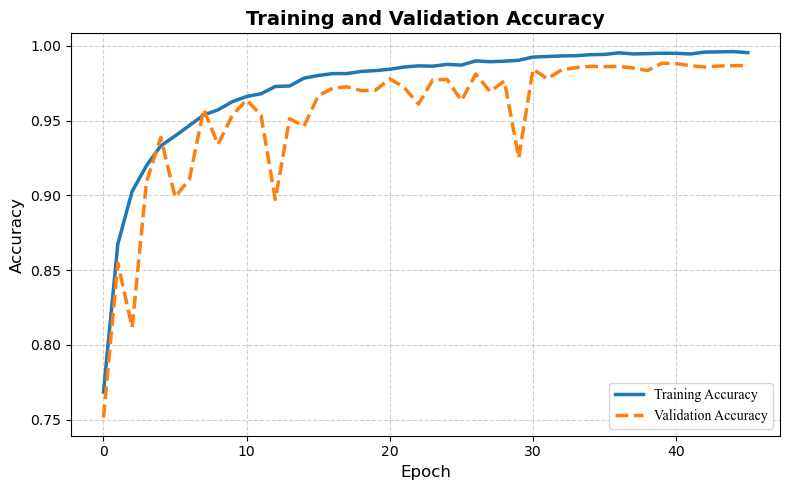

In [6]:
# --- Vẽ kết quả ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Thiết lập phong cách hiện đại ---
## Hoặc sns.set_palette("muted") và nền trắng sns.set_style("ticks") sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")
plt.figure(figsize=(8,5))

# --- Vẽ các đường ---
plt.plot(history.history['accuracy'], 
         label='Training Accuracy', 
         color='#1f77b4', 
         linewidth=2.5)

plt.plot(history.history['val_accuracy'], 
         label='Validation Accuracy', 
         color='#ff7f0e', 
         linewidth=2.5, 
         linestyle='--')

# --- Trang trí biểu đồ ---
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.rcParams['font.family'] = 'Times New Roman'
plt.legend(frameon=True, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# --- Lưu lại file JPEG chất lượng cao ---
plt.savefig('D:/CatTuong/ALOS_Processing/classification_output/CNN_part3_Oct29.jpeg', format='jpeg', dpi=300, bbox_inches='tight')

In [7]:
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_val_enc

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes, digits=3))


  1/135 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step

 21/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

 42/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 64/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 85/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

102/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

120/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


[[1499   15    2    0    0]
 [  13 1458    7    0    0]
 [  11    3  482    0    0]
 [   0    0    0   11    0]
 [   0    0    0    0  813]]
              precision    recall  f1-score   support

           0      0.984     0.989     0.987      1516
           1      0.988     0.986     0.987      1478
           2      0.982     0.972     0.977       496
           3      1.000     1.000     1.000        11
           4      1.000     1.000     1.000       813

    accuracy                          0.988      4314
   macro avg      0.991     0.989     0.990      4314
weighted avg      0.988     0.988     0.988      4314

